In [1]:
#Loading dataset from the UCI ML Repository (includes the dataframes and metadata information).
!pip3 install -U ucimlrepo 

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
tic_tac_toe_endgame = fetch_ucirepo(id=101) 
  
# data (as pandas dataframes) 
X = tic_tac_toe_endgame.data.features 
y = tic_tac_toe_endgame.data.targets 
  
# metadata 
print(tic_tac_toe_endgame.metadata) 
  
# variable information 
print(tic_tac_toe_endgame.variables) 



{'uci_id': 101, 'name': 'Tic-Tac-Toe Endgame', 'repository_url': 'https://archive.ics.uci.edu/dataset/101/tic+tac+toe+endgame', 'data_url': 'https://archive.ics.uci.edu/static/public/101/data.csv', 'abstract': 'Binary classification task on possible configurations of tic-tac-toe game', 'area': 'Games', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 958, 'num_features': 9, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Mon Aug 19 1991', 'dataset_doi': '10.24432/C5688J', 'creators': ['David Aha'], 'intro_paper': None, 'additional_info': {'summary': 'This database encodes the complete set of possible board configurations at the end of tic-tac-toe games, where "x" is assumed to have played first.  The target concept is "win for x" (i.e., true when "x" has one of 8 possible ways to create a "three

In [10]:
# exploring dataset 
# See all keys in the metadata
import pandas as pd

print(tic_tac_toe_endgame.metadata.keys())

# Print the entire metadata dictionary
for key, value in tic_tac_toe_endgame.metadata.items():
    print(f"{key}: {value}")


dict_keys(['uci_id', 'name', 'repository_url', 'data_url', 'abstract', 'area', 'tasks', 'characteristics', 'num_instances', 'num_features', 'feature_types', 'demographics', 'target_col', 'index_col', 'has_missing_values', 'missing_values_symbol', 'year_of_dataset_creation', 'last_updated', 'dataset_doi', 'creators', 'intro_paper', 'additional_info'])
uci_id: 101
name: Tic-Tac-Toe Endgame
repository_url: https://archive.ics.uci.edu/dataset/101/tic+tac+toe+endgame
data_url: https://archive.ics.uci.edu/static/public/101/data.csv
abstract: Binary classification task on possible configurations of tic-tac-toe game
area: Games
tasks: ['Classification']
characteristics: ['Multivariate']
num_instances: 958
num_features: 9
feature_types: ['Categorical']
demographics: []
target_col: ['class']
index_col: None
has_missing_values: no
missing_values_symbol: None
year_of_dataset_creation: 1991
last_updated: Mon Aug 19 1991
dataset_doi: 10.24432/C5688J
creators: ['David Aha']
intro_paper: None
addition

In [11]:
# Combining features and target into one DataFrame
import pandas as pd

df = pd.concat([X, y], axis=1)

# Renaming the target column 
df = df.rename(columns={df.columns[-1]: "class"})

#Printing the first few rows using data.head()
print(df.head())   

#Checking the data types of each column using data.info().
print(df.info()) 

#Getting summary statistics using data.describe().

print(df.describe())   

  top-left-square top-middle-square top-right-square middle-left-square  \
0               x                 x                x                  x   
1               x                 x                x                  x   
2               x                 x                x                  x   
3               x                 x                x                  x   
4               x                 x                x                  x   

  middle-middle-square middle-right-square bottom-left-square  \
0                    o                   o                  x   
1                    o                   o                  o   
2                    o                   o                  o   
3                    o                   o                  o   
4                    o                   o                  b   

  bottom-middle-square bottom-right-square     class  
0                    o                   o  positive  
1                    x                   o  posi

In [12]:
#in order to compute correlations and run statistics, next is to encode the categorical values (x, o, b) 
# checking for frequency of values in each square
for col in df.columns[:-1]:
    print(f"\n{col}:\n", df[col].value_counts())

# Target distribution
print("\nClass distribution:\n", df['class'].value_counts())


top-left-square:
 x    418
o    335
b    205
Name: top-left-square, dtype: int64

top-middle-square:
 x    378
o    330
b    250
Name: top-middle-square, dtype: int64

top-right-square:
 x    418
o    335
b    205
Name: top-right-square, dtype: int64

middle-left-square:
 x    378
o    330
b    250
Name: middle-left-square, dtype: int64

middle-middle-square:
 x    458
o    340
b    160
Name: middle-middle-square, dtype: int64

middle-right-square:
 x    378
o    330
b    250
Name: middle-right-square, dtype: int64

bottom-left-square:
 x    418
o    335
b    205
Name: bottom-left-square, dtype: int64

bottom-middle-square:
 x    378
o    330
b    250
Name: bottom-middle-square, dtype: int64

bottom-right-square:
 x    418
o    335
b    205
Name: bottom-right-square, dtype: int64

Class distribution:
 positive    626
negative    332
Name: class, dtype: int64


In [13]:
#Encode Categorical Values.We’ll use LabelEncoder from scikit-learn. It converts each unique category into an integer.

from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid overwriting original
df_encoded = df.copy()

# Apply LabelEncoder to every column
encoder = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

print(df_encoded.head())

   top-left-square  top-middle-square  top-right-square  middle-left-square  \
0                2                  2                 2                   2   
1                2                  2                 2                   2   
2                2                  2                 2                   2   
3                2                  2                 2                   2   
4                2                  2                 2                   2   

   middle-middle-square  middle-right-square  bottom-left-square  \
0                     1                    1                   2   
1                     1                    1                   1   
2                     1                    1                   1   
3                     1                    1                   1   
4                     1                    1                   0   

   bottom-middle-square  bottom-right-square  class  
0                     1                    1      1  
1       

In [14]:
#after encoding, we can find 
# Mean
print("Mean:\n", import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.show()
# Median
print("\nMedian:\n", df_encoded.median())

# Mode (can be multiple, so take the first row)
print("\nMode:\n", df_encoded.mode().iloc[0])

# Standard Deviation
print("\nStandard Deviation:\n", df_encoded.std())

Mean:
 top-left-square         1.222338
top-middle-square       1.133612
top-right-square        1.222338
middle-left-square      1.133612
middle-middle-square    1.311065
middle-right-square     1.133612
bottom-left-square      1.222338
bottom-middle-square    1.133612
bottom-right-square     1.222338
class                   0.653445
dtype: float64

Median:
 top-left-square         1.0
top-middle-square       1.0
top-right-square        1.0
middle-left-square      1.0
middle-middle-square    1.0
middle-right-square     1.0
bottom-left-square      1.0
bottom-middle-square    1.0
bottom-right-square     1.0
class                   1.0
dtype: float64

Mode:
 top-left-square         2
top-middle-square       2
top-right-square        2
middle-left-square      2
middle-middle-square    2
middle-right-square     2
bottom-left-square      2
bottom-middle-square    2
bottom-right-square     2
class                   1
Name: 0, dtype: int32

Standard Deviation:
 top-left-square         0.77556

In [15]:
#Calculating the correlation between different features using data.corr().
# Correlation matrix
print("\nCorrelation Matrix:\n", df_encoded.corr())


Correlation Matrix:
                       top-left-square  top-middle-square  top-right-square  \
top-left-square              1.000000           0.002598         -0.061424   
top-middle-square            0.002598           1.000000          0.002598   
top-right-square            -0.061424           0.002598          1.000000   
middle-left-square           0.002598          -0.101657         -0.154229   
middle-middle-square        -0.095030          -0.049103         -0.095030   
middle-right-square         -0.154229          -0.101657          0.002598   
bottom-left-square          -0.061424          -0.154229         -0.026680   
bottom-middle-square        -0.154229           0.050578         -0.154229   
bottom-right-square         -0.026680          -0.154229         -0.061424   
class                        0.039097          -0.084167          0.039097   

                      middle-left-square  middle-middle-square  \
top-left-square                 0.002598             

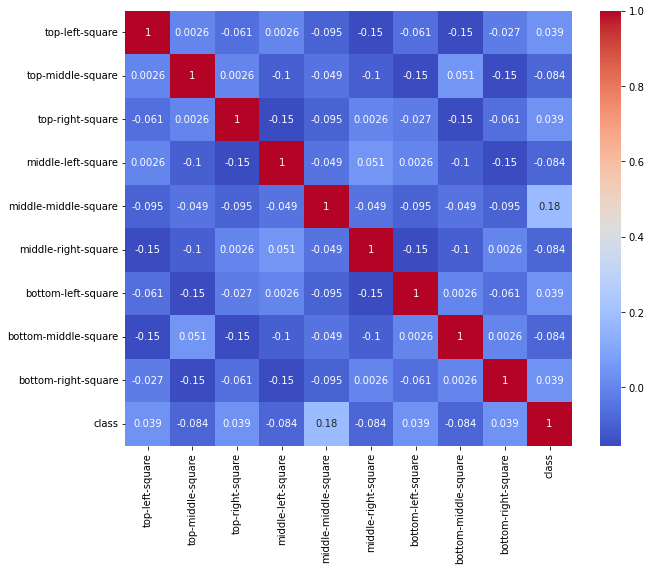

In [17]:
#visualizing correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.show()